In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Contoh dataset (buat dummy data)
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100)

# Evaluasi
print("Prediksi:", model.predict(X_test))

Epoch 1/100


c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.5706
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1.5577
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.5448
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.5320
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 1.5193
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.5066
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.4940
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.4815
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.4691
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.4567
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.4444
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.4322
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.4201
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.4080
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.3960
Epoch 16/100
1/1 ━━━━━━━━━━━━━━

Tugas 4:

Ubah learning rate.

Bandingkan hasil loss.


--- Training dengan Learning Rate = 0.001 ---


c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training dengan Learning Rate = 0.01 ---

--- Training dengan Learning Rate = 0.05 ---

--- Training dengan Learning Rate = 0.1 ---

--- Training dengan Learning Rate = 0.3 ---

--- Training dengan Learning Rate = 0.5 ---


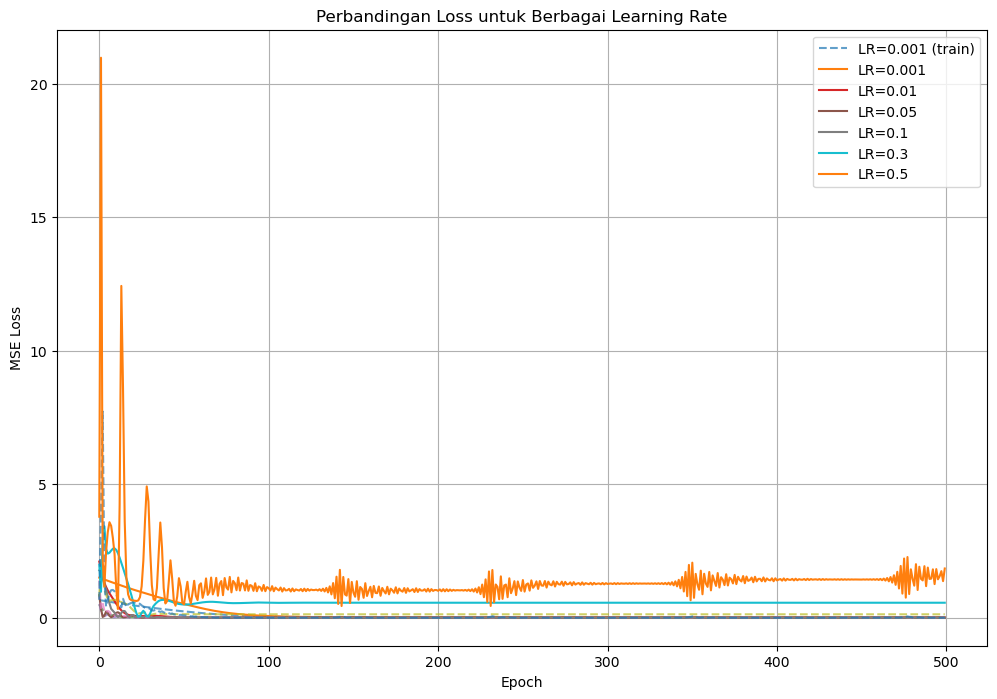


RINGKASAN HASIL AKHIR (setelah 500 epoch)
Learning Rate   Train Loss      Val Loss        Keterangan
------------------------------------------------------------
0.001           0.000055        0.004419        Sangat Bagus
0.01            0.000000        0.003576        Sangat Bagus
0.05            0.000000        0.000018        Sangat Bagus
0.1             0.000000        0.000176        Sangat Bagus
0.3             0.128205        0.561189        Buruk / Divergen
0.5             0.003399        1.842989        Buruk / Divergen


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

# --------------------- Dummy Data ---------------------
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90, 55, 65, 75, 85, 95, 45, 100],
    'harga': [500, 600, 700, 800, 900, 550, 650, 750, 850, 950, 450, 1000]
})

X = data[['luas']].values
y = data[['harga']].values.reshape(-1, 1)

# Normalisasi
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --------------------- Fungsi untuk train model dengan learning rate tertentu ---------------------
def train_model(learning_rate, epochs=500, verbose=0):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    
    history = model.fit(X_train, y_train, 
                        epochs=epochs, 
                        validation_data=(X_test, y_test),
                        verbose=verbose)
    
    return history, model

# --------------------- Eksperimen dengan berbagai learning rate ---------------------
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
histories = {}
final_losses = {}

plt.figure(figsize=(12, 8))

for lr in learning_rates:
    print(f"\n--- Training dengan Learning Rate = {lr} ---")
    history, _ = train_model(learning_rate=lr, epochs=500, verbose=0)
    histories[lr] = history
    
    val_loss_final = history.history['val_loss'][-1]
    train_loss_final = history.history['loss'][-1]
    final_losses[lr] = (train_loss_final, val_loss_final)
    
    # Plot training & validation loss
    plt.plot(history.history['loss'], label=f'LR={lr} (train)' if lr == learning_rates[0] else None, 
             linestyle='--', alpha=0.7)
    plt.plot(history.history['val_loss'], label=f'LR={lr}')

# --------------------- Hasil perbandingan ---------------------
plt.title('Perbandingan Loss untuk Berbagai Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Tabel ringkasan
print("\n" + "="*60)
print("RINGKASAN HASIL AKHIR (setelah 500 epoch)")
print("="*60)
print(f"{'Learning Rate':<15} {'Train Loss':<15} {'Val Loss':<15} {'Keterangan'}")
print("-"*60)
for lr in learning_rates:
    train_l, val_l = final_losses[lr]
    if val_l < 0.01:
        ket = "Sangat Bagus"
    elif val_l < 0.05:
        ket = "Baik"
    elif val_l < 0.2:
        ket = "Sedang"
    else:
        ket = "Buruk / Divergen"
    print(f"{lr:<15} {train_l:<15.6f} {val_l:<15.6f} {ket}")

Ukuran dataset: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6535 - mae: 0.5483 - val_loss: 0.3845 - val_mae: 0.4314
Epoch 2/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3556 - mae: 0.4209 - val_loss: 0.3651 - val_mae: 0.4129
Epoch 3/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3365 - mae: 0.4026 - val_loss: 0.3402 - val_mae: 0.4141
Epoch 4/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3225 - mae: 0.3939 - val_loss: 0.3160 - val_mae: 0.3934
Epoch 5/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3376 - mae: 0.3872 - val_loss: 0.3277 - val_mae: 0.4090
Epoch 6/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2982 - mae: 0.3781 - val_loss: 0.3023 - val_mae: 0.3841
Epoch 7/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2952 - mae: 0.3723 - val_loss: 0.3068 - val_mae: 0.3832
Epoch 8/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2866 - mae: 0.3675 - val_loss: 0.3124 - val_mae: 0.3692
Epoch 9/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s

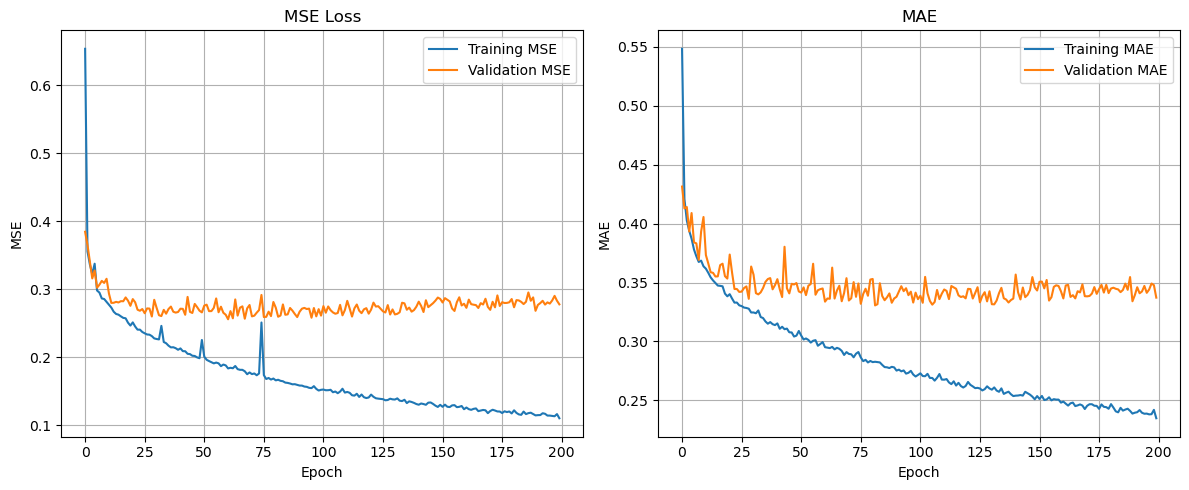

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Final Results (California Housing Dataset)
RMSE : 0.5272 (x $100,000)
MAE  : 0.3372 (x $100,000)


In [5]:
# MLP Regresi dengan Keras/TensorFlow (Versi yang sudah DIPERBAIKI & BERJALAN)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Load dataset (pengganti load_boston)
data = fetch_california_housing()
X = data.data
y = data.target                     # harga rumah dalam 100.000 USD

print(f"Ukuran dataset: {X.shape}")   # (20640, 8)
print(f"Feature names: {data.feature_names}")

# 2. Preprocessing
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    Xs, y, test_size=0.2, random_state=42
)

# 3. Bangun model MLP
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)                              # output regresi
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model.summary())

# 4. Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

# 5. Plot loss & MAE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.title('MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Evaluasi akhir
pred = model.predict(X_val).flatten()

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae = mean_absolute_error(y_val, pred)

print("\n" + "="*50)
print(f"Final Results (California Housing Dataset)")
print(f"RMSE : {rmse:.4f} (x $100,000)")
print(f"MAE  : {mae:.4f} (x $100,000)")
print("="*50)